In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import scipy
import PIL
import requests
import plotly.graph_objects as go


In [3]:
df = pd.read_csv(r'C:\Users\kaurp\visualization\02_activities\assignments\Ontario housing data.csv', delimiter=',', encoding='utf-8')
print(df.head())

   _id               Municipality  Ten-year housing target  \
0  409                       Ajax                    17000   
1  410                     Aurora                     8000   
2  411                     Barrie                    23000   
3  412                 Belleville                     3100   
4  413  Bradford West Gwillimbury                     6500   

   Total housing progress since 2022  Target for 2024  \
0                               1801             1417   
1                                641              667   
2                               4782             1917   
3                               1140              258   
4                                991              542   

   Total 2024 housing progress Progress % for 2024 Housing Target Status  
0                          163              11.50%               Not met  
1                          167              25.04%               Not met  
2                          791              41.26%         

In [168]:
print(df.dtypes) ## checking data types

_id                                   int64
Municipality                         object
Ten-year housing target               int64
Total housing progress since 2022     int64
Target for 2024                       int64
Total 2024 housing progress           int64
Progress % for 2024                  object
Housing Target Status                object
dtype: object


In [4]:
# Convert data into float
df['Progress % for 2024'] = df['Progress % for 2024'].str.replace('%', '')
df['Progress % for 2024'] = pd.to_numeric(df['Progress % for 2024'], errors='coerce')
print(df['Progress % for 2024'].dtype)

float64


In [5]:
print(df['Progress % for 2024'].unique())

[ 11.5   25.04  41.26  82.56  44.1   52.11  33.61  31.2   51.06  39.55
 147.83  53.92  29.89  43.13  72.56  56.6   26.29  33.59  41.66  49.52
  61.25  67.77  69.87  76.9   39.41  95.6   32.77  43.34  19.9   72.11
  32.63 277.11 122.98  46.27  47.74  59.44 156.6   33.42 180.72 144.
  28.24 134.43  77.57  67.09  64.29 106.7   37.13   7.75 134.44  22.93
  56.15]


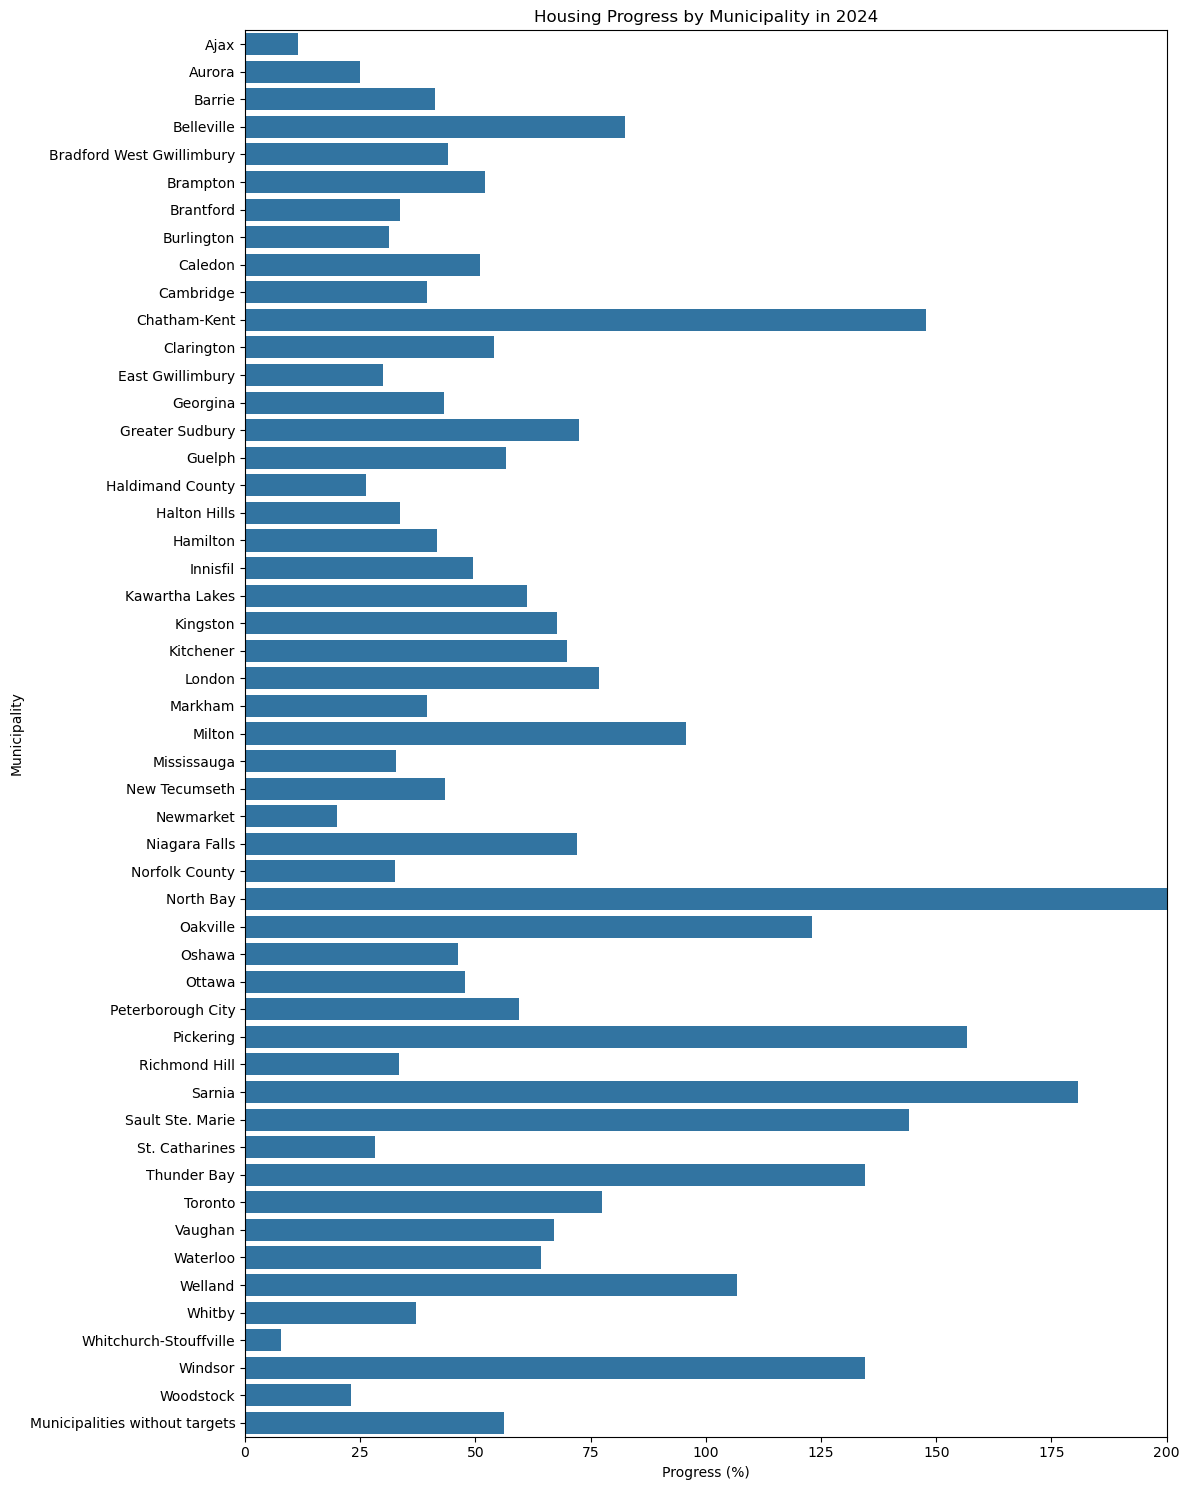

In [6]:
# Create the plot for Housing progress by Municipality in 2024
fig, ax = plt.subplots(figsize=(12, 15))

# Use a horizontal bar plot
sns.barplot(data=df, y='Municipality', x='Progress % for 2024', ax=ax)

# Customize the plot
plt.title('Housing Progress by Municipality in 2024')
plt.xlabel('Progress (%)')
plt.ylabel('Municipality')
ax.set_xlim(0, 200)  # Set x-axis limits 
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

# SUBPLOTS
# Housing progress by Municipality in 2024 and Total progress since 2022

C:\Users\kaurp\AppData\Local\Temp\ipykernel_16960\770514886.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, y='Municipality', x='Progress % for 2024', ax=axes[0], orient='h', palette='viridis')
C:\Users\kaurp\AppData\Local\Temp\ipykernel_16960\770514886.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, y='Municipality', x='Total housing progress since 2022', ax=axes[1], orient='h', palette='coolwarm')


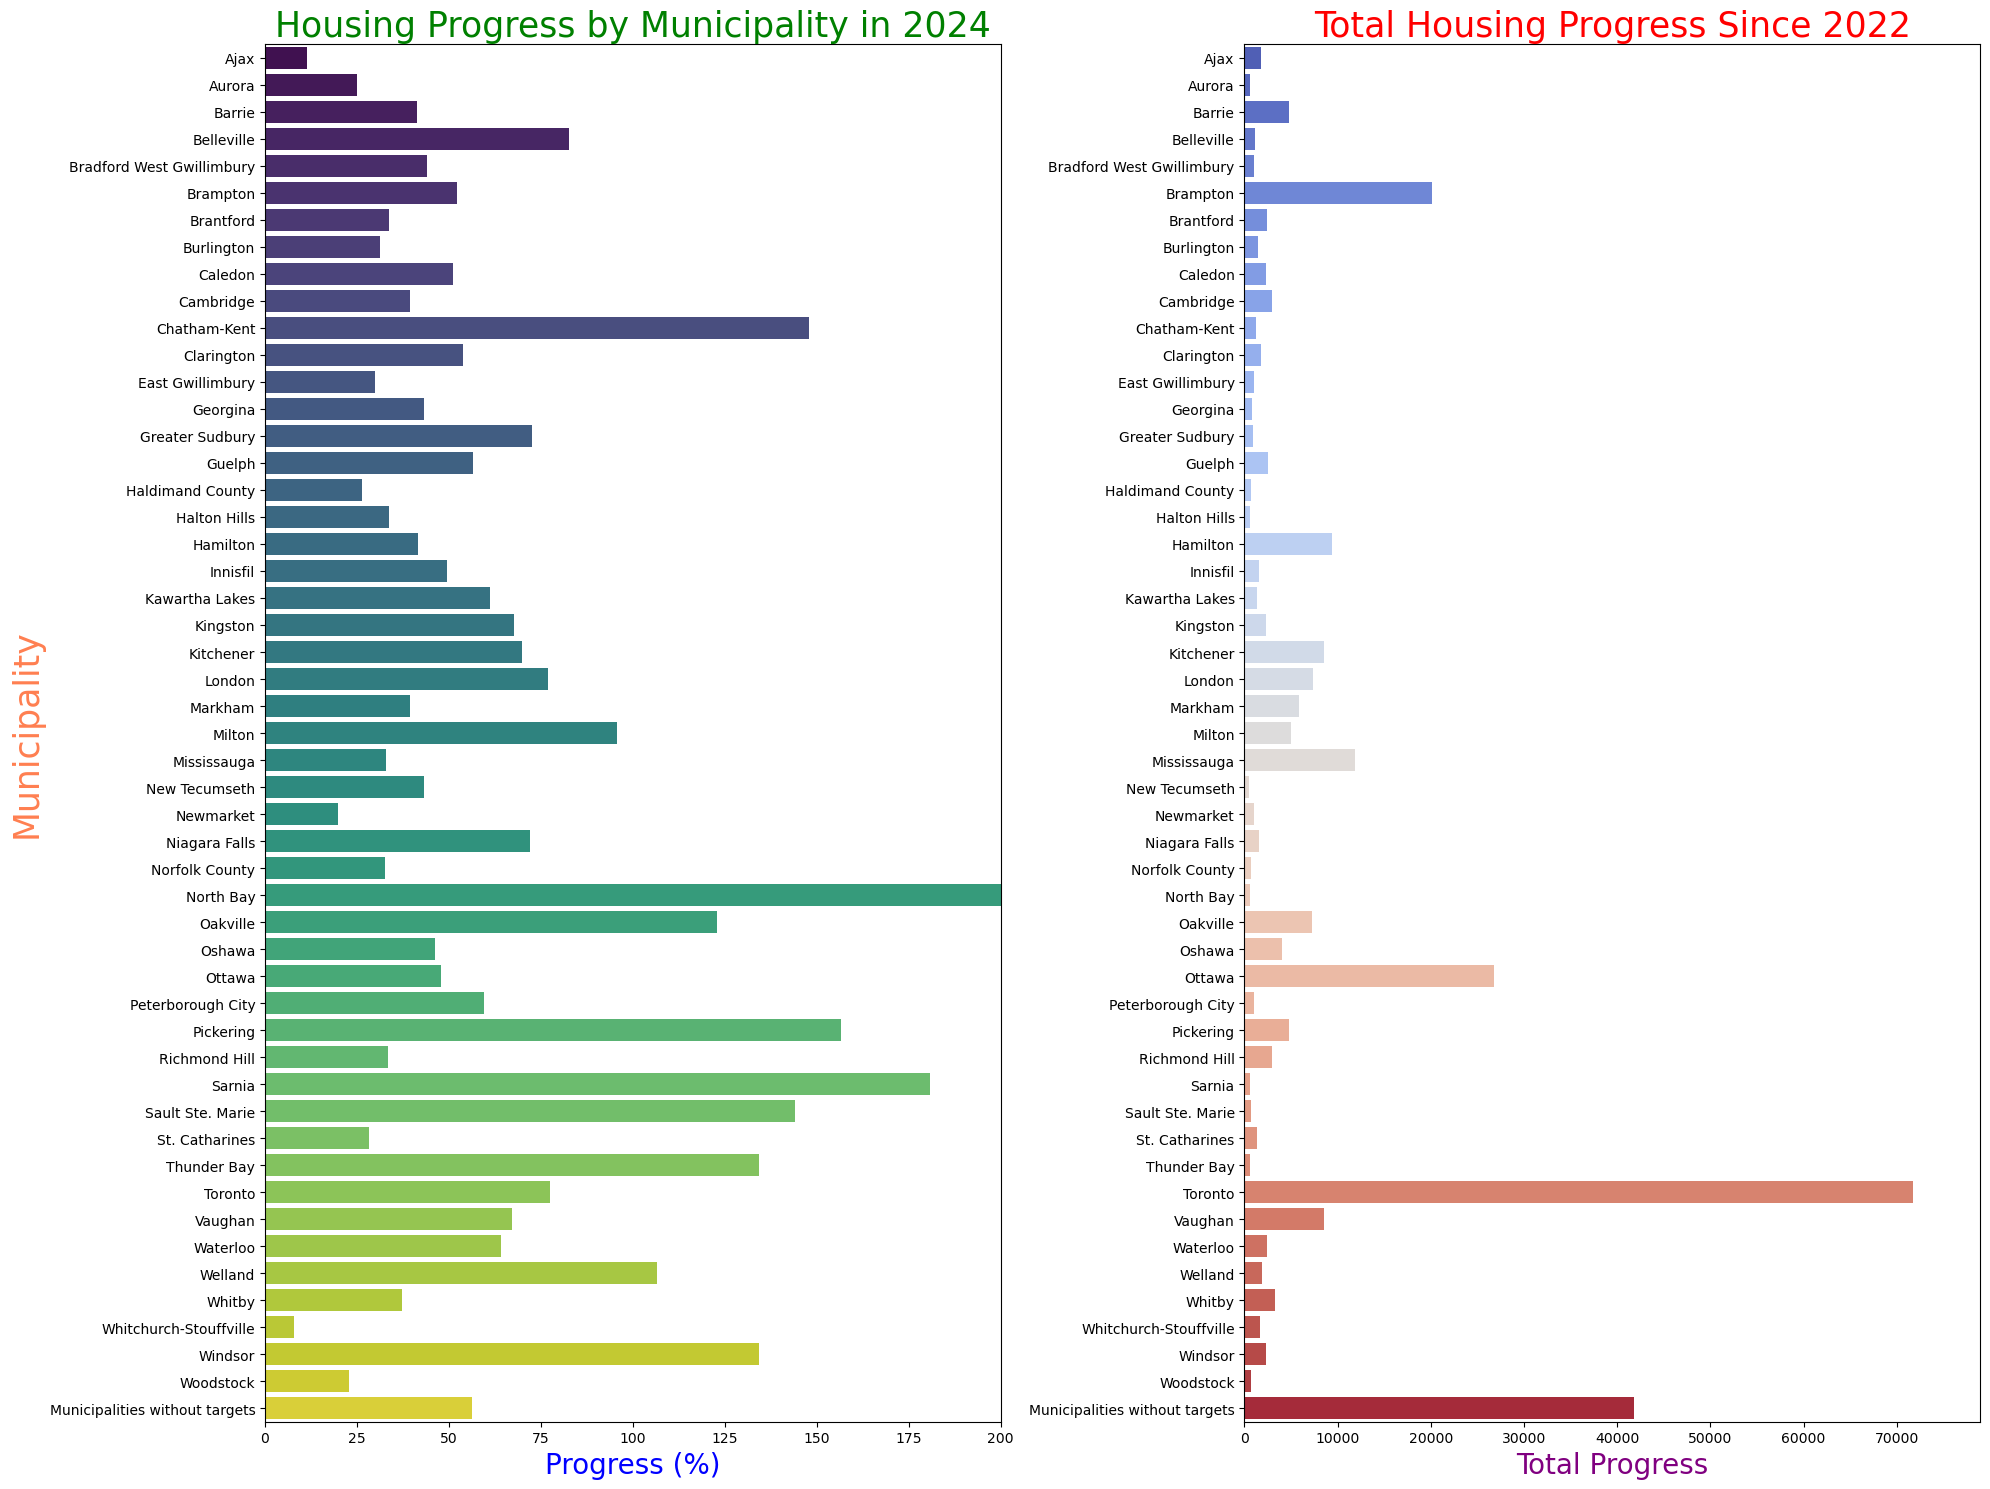

In [7]:
# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 15))

# Subplot 1: Horizontal bar plot for 'Progress % for 2024'
sns.barplot(data=df, y='Municipality', x='Progress % for 2024', ax=axes[0], orient='h', palette='viridis')
axes[0].set_title('Housing Progress by Municipality in 2024', fontsize=25, color = 'Green')
axes[0].set_xlabel('Progress (%)', fontsize=20, color= 'Blue')
axes[0].set_ylabel('Municipality', fontsize=25, color= 'Coral')
axes[0].set_xlim(0, 200)  # Set x-axis limits explicitly

# Subplot 2: Horizontal bar plot for 'Total housing progress since 2022'
sns.barplot(data=df, y='Municipality', x='Total housing progress since 2022', ax=axes[1], orient='h', palette='coolwarm')
axes[1].set_title('Total Housing Progress Since 2022', fontsize=25, color = 'red')
axes[1].set_xlabel('Total Progress', fontsize=20, color= 'purple')
axes[1].set_ylabel('')  # Hide y-axis label for the second subplot
axes[1].set_xlim(0, df['Total housing progress since 2022'].max() * 1.1)  # Set x-axis limit

# Adjust layout
plt.tight_layout()
plt.show()

# PAIRPLOTS

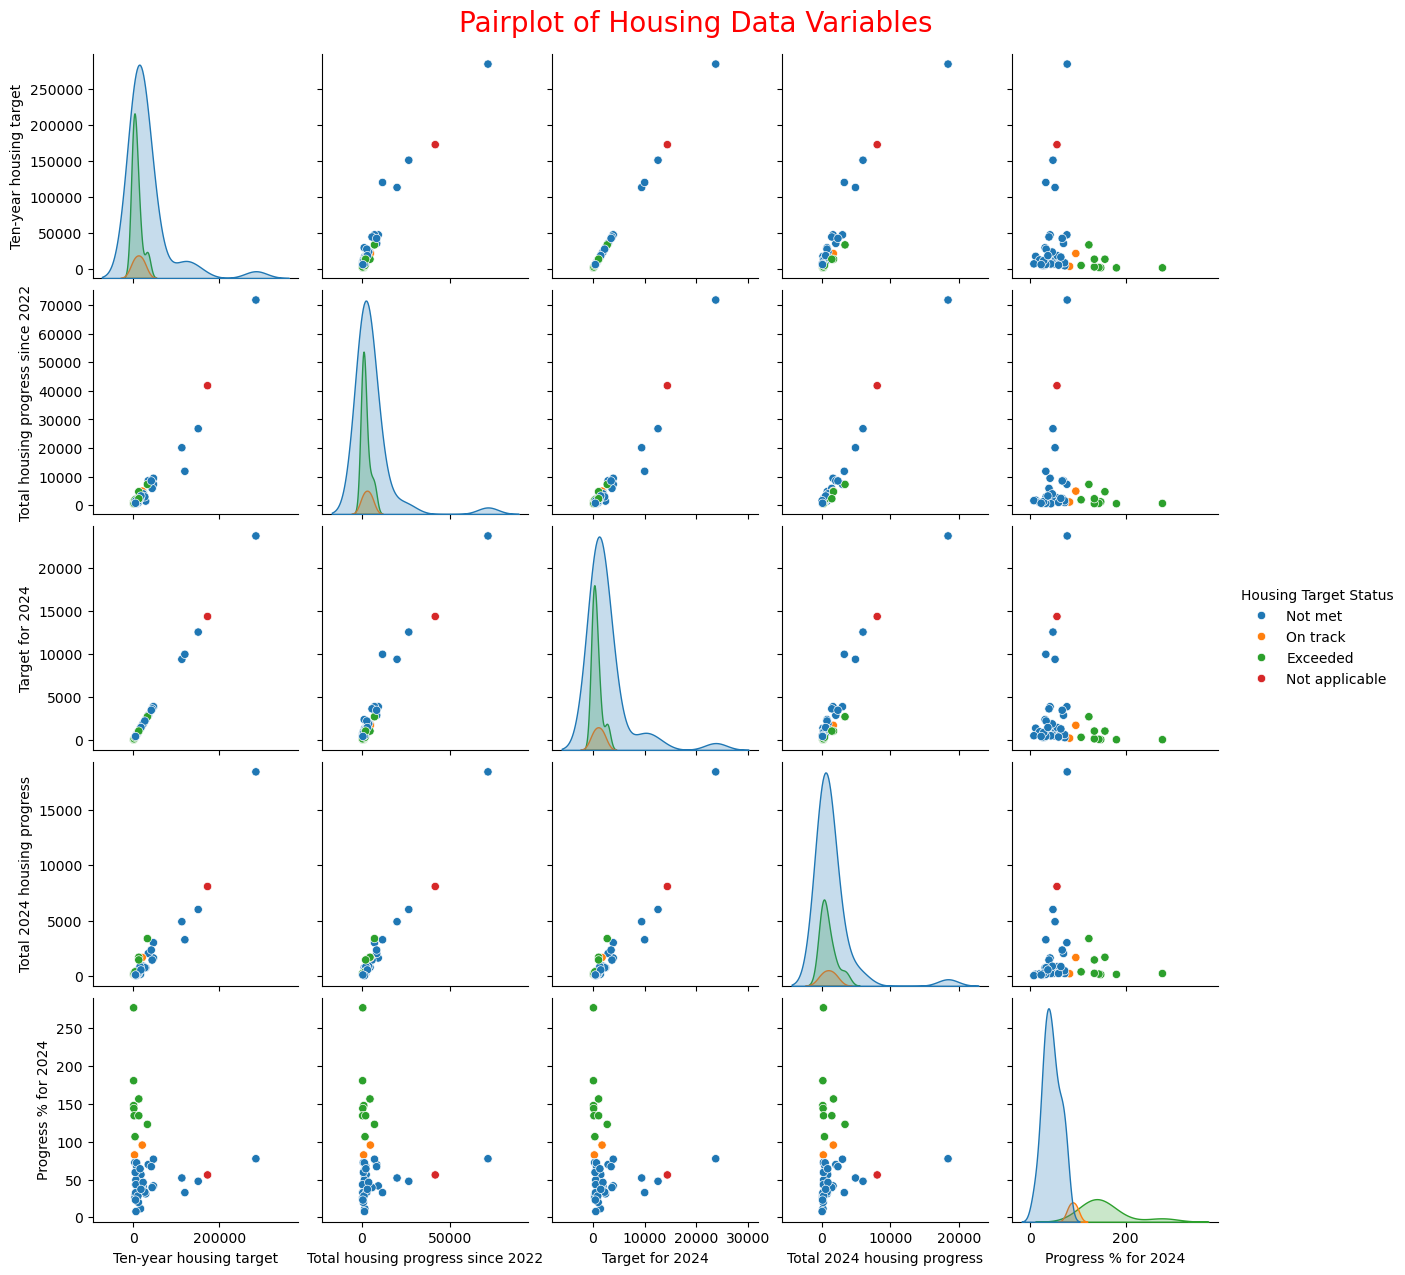

In [8]:
# Create pairplot
sns.pairplot(df, vars=[
    'Ten-year housing target', 
    'Total housing progress since 2022', 
    'Target for 2024', 
    'Total 2024 housing progress', 
    'Progress % for 2024'], hue='Housing Target Status')
plt.suptitle('Pairplot of Housing Data Variables', y=1.02, color = 'Red', fontsize= 20)  # creating super title for pairplots
plt.show()

# REPLOTS

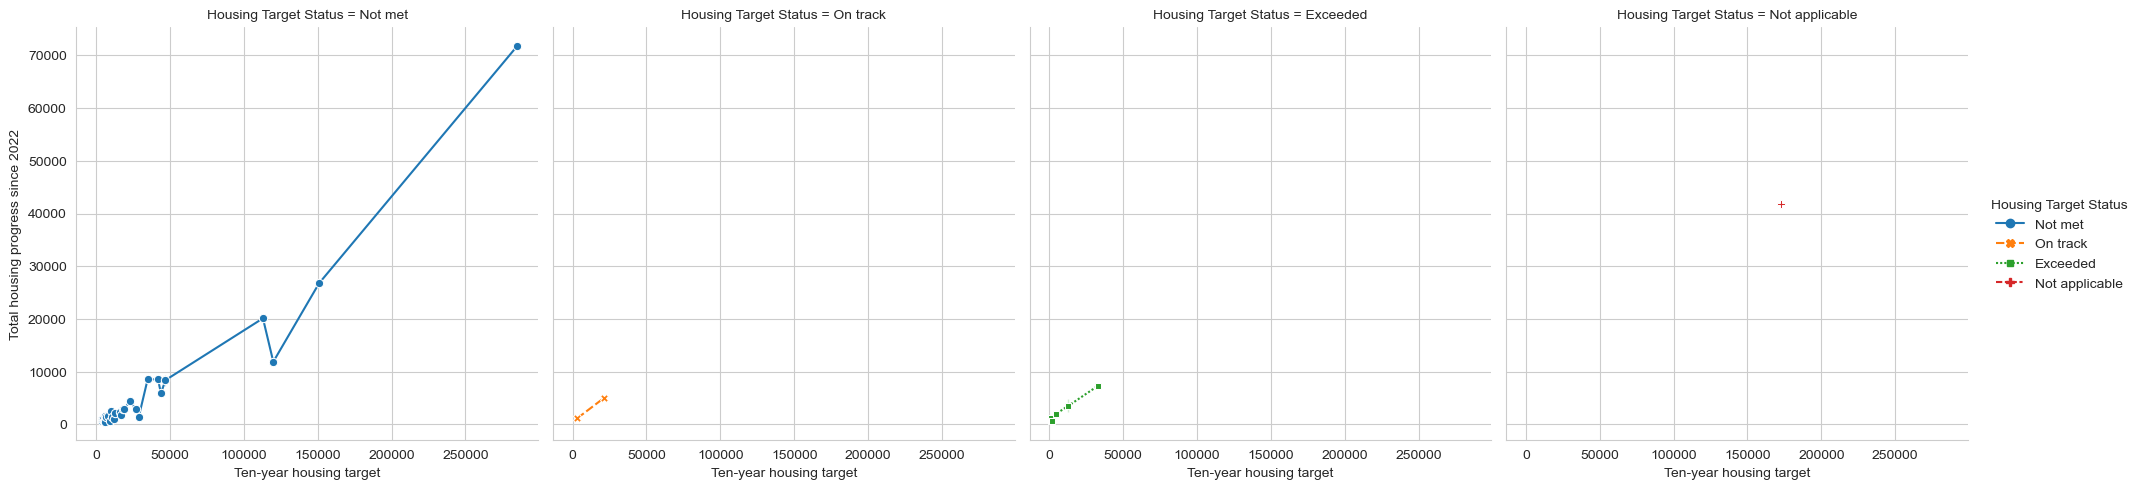

In [ ]:
# Replot for Total Housing Progress since 2022 and Ten year target
sns.set_style("whitegrid") 
sns.relplot(data=df, x='Ten-year housing target', y='Total housing progress since 2022', 
            hue='Housing Target Status', style='Housing Target Status', 
            col='Housing Target Status', col_wrap=4, kind='line', markers=True,)
plt.show()

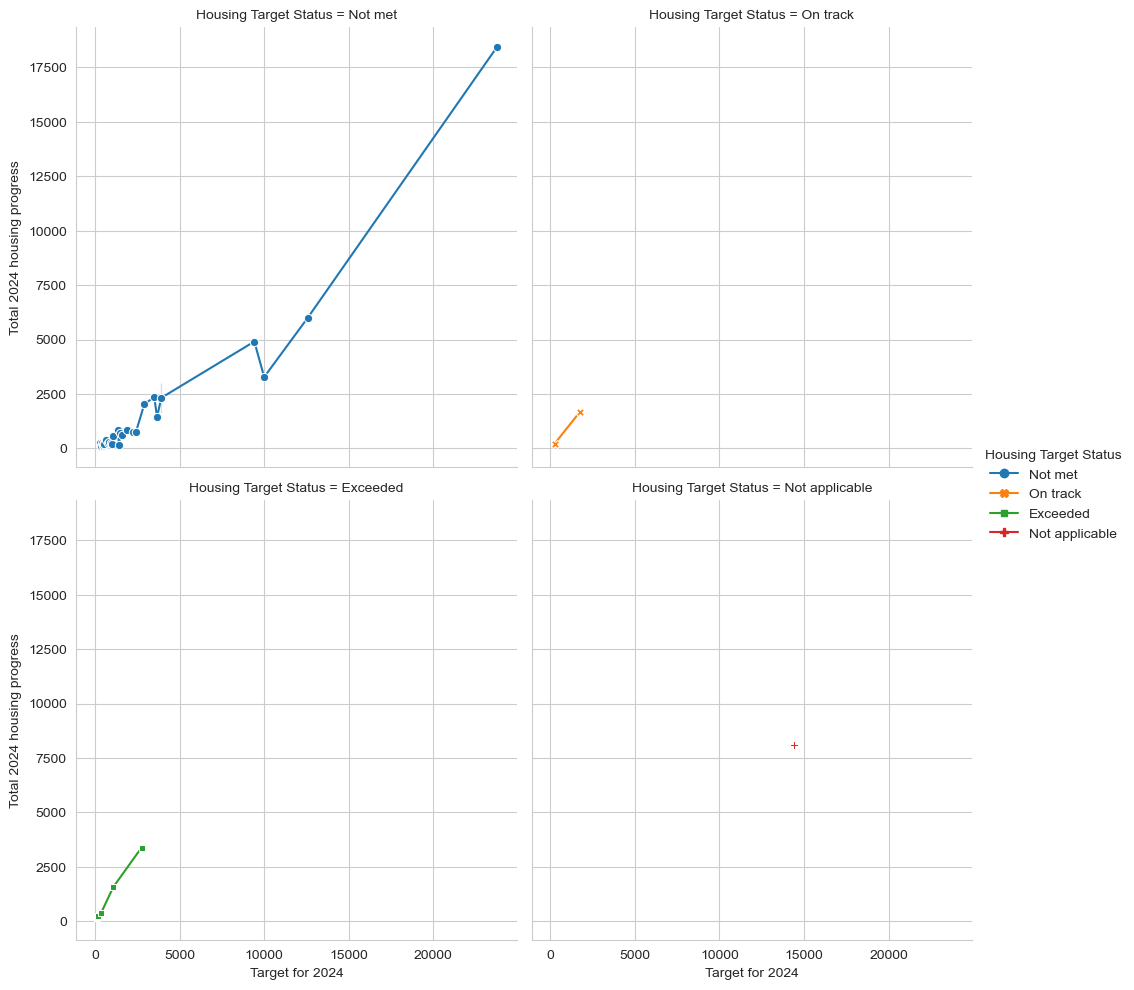

In [9]:
# Replot for Target for 2024 and Total 2024 progress
sns.set_style("whitegrid") 
sns.relplot(data=df, x='Target for 2024', y='Total 2024 housing progress', 
            hue='Housing Target Status', style='Housing Target Status', 
            col='Housing Target Status', col_wrap=2, kind='line', markers=True,  dashes=False)
plt.show()

# Interactive Graph for Housing Progress in 2024 by Target Status

In [10]:
graph = go.Figure()

# Add traces for each Housing Target Status
for status in df['Housing Target Status'].unique():
    subset = df[df['Housing Target Status'] == status]
    graph.add_trace(go.Scatter(
        x=subset['Target for 2024'],  # X-axis: Target for 2024
        y=subset['Total 2024 housing progress'],  # Y-axis: Total 2024 housing progress
        mode='markers',  # Use markers for scatter plot
        name=status,  # Legend name
        marker=dict(
            size=15,  # Marker size
            opacity=0.8,  # Marker opacity
            line=dict(width=2, color='black')  # Marker border
        ),
        text=subset['Municipality'],  # Show municipality name on hover
        hoverinfo='text+x+y')) # Display municipality name, x, and y on hover


# Update layout
graph.update_layout(
    title='Housing Progress in 2024 by Target Status',  # Title
    xaxis_title='Target for 2024',  # X-axis label
    yaxis_title='Total 2024 Housing Progress',  # Y-axis label
    width=800, 
    height=600,
    template='plotly_white') # Use a white theme



graph.show()